In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# STEP 2: CREATE HYPOTHETICAL LOGISTICS DATASET

np.random.seed(42)

n = 500

logistics_data = {
    "Order_ID": range(1, n + 1),
    "Delivery_Days": np.random.randint(1, 16, n),
    "Shipment_Volume": np.round(np.random.uniform(1, 100, n), 2),
    "Transportation_Cost": np.round(np.random.uniform(500, 10000, n), 2),
    "Distance_km": np.random.randint(10, 1000, n),
    "Shipment_Weight_kg": np.round(np.random.uniform(1, 500, n), 2),
    "Customer_Rating": np.round(np.random.uniform(1, 5, n), 1),
    "Shipping_Mode": np.random.choice(
        ["Road", "Rail", "Air", "Sea"], n
    ),
    "Delivery_Status": np.random.choice(
        ["On Time", "Late"], n, p=[0.75, 0.25]
    )
}

df = pd.DataFrame(logistics_data)

print("Dataset created successfully!")
print("Shape:", df.shape)

df.head()

Dataset created successfully!
Shape: (500, 9)


,Order_ID,Delivery_Days,Shipment_Volume,Transportation_Cost,Distance_km,Shipment_Weight_kg,Customer_Rating,Shipping_Mode,Delivery_Status
0,1,7,26.36,4841.50,111,358.36,2.9,Air,Late
1,2,4,61.54,6237.60,434,137.04,4.9,Rail,Late
2,3,13,9.08,5271.74,401,207.36,3.4,Air,Late
3,4,15,1.51,5628.68,788,61.82,2.4,Air,On Time
4,5,11,63.16,5120.40,223,91.39,1.5,Road,Late


In [4]:
# STEP 3: BASIC EDA

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nDescriptive Statistics:")
print(df.describe())

Dataset Shape: (500, 9)

Column Names:
['Order_ID', 'Delivery_Days', 'Shipment_Volume', 'Transportation_Cost', 'Distance_km', 'Shipment_Weight_kg', 'Customer_Rating', 'Shipping_Mode', 'Delivery_Status']

Data Types:
Order_ID                 int64
Delivery_Days            int64
Shipment_Volume        float64
Transportation_Cost    float64
Distance_km              int64
Shipment_Weight_kg     float64
Customer_Rating        float64
Shipping_Mode           object
Delivery_Status         object
dtype: object

Missing Values:
Order_ID               0
Delivery_Days          0
Shipment_Volume        0
Transportation_Cost    0
Distance_km            0
Shipment_Weight_kg     0
Customer_Rating        0
Shipping_Mode          0
Delivery_Status        0
dtype: int64

Duplicate Rows:
0

Descriptive Statistics:
         Order_ID  Delivery_Days  Shipment_Volume  Transportation_Cost  \
count  500.000000     500.000000       500.000000           500.000000   
mean   250.500000       7.846000        50.7

In [5]:
# STEP 4: CENTRAL TENDENCIES

numeric_cols = [
    "Delivery_Days",
    "Shipment_Volume",
    "Transportation_Cost",
    "Distance_km",
    "Shipment_Weight_kg",
    "Customer_Rating"
]

central_tendency = pd.DataFrame({
    "Mean": df[numeric_cols].mean(),
    "Median": df[numeric_cols].median(),
    "Standard_Deviation": df[numeric_cols].std()
})

print(central_tendency)

                           Mean    Median  Standard_Deviation
Delivery_Days           7.84600     8.000            4.367199
Shipment_Volume        50.71300    52.080           28.219373
Transportation_Cost  5347.25318  5452.165         2781.402046
Distance_km           513.77400   506.000          297.998377
Shipment_Weight_kg    248.71160   254.115          144.024642
Customer_Rating         3.02280     3.000            1.146363


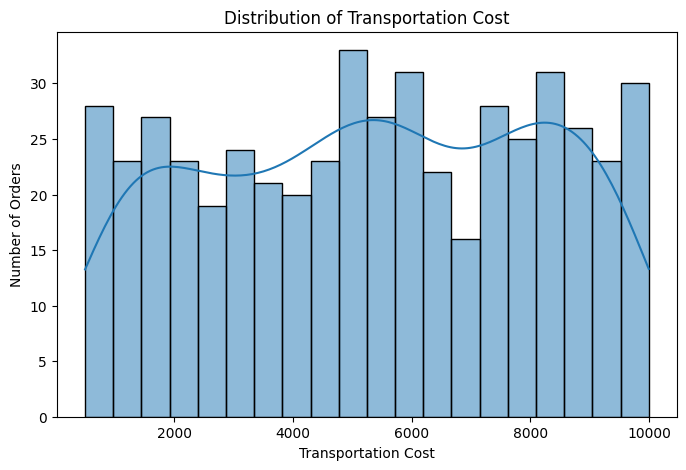

In [6]:
# STEP 6: TRANSPORTATION COST DISTRIBUTION

plt.figure(figsize=(8,5))
sns.histplot(df["Transportation_Cost"], bins=20, kde=True)
plt.title("Distribution of Transportation Cost")
plt.xlabel("Transportation Cost")
plt.ylabel("Number of Orders")
plt.show()

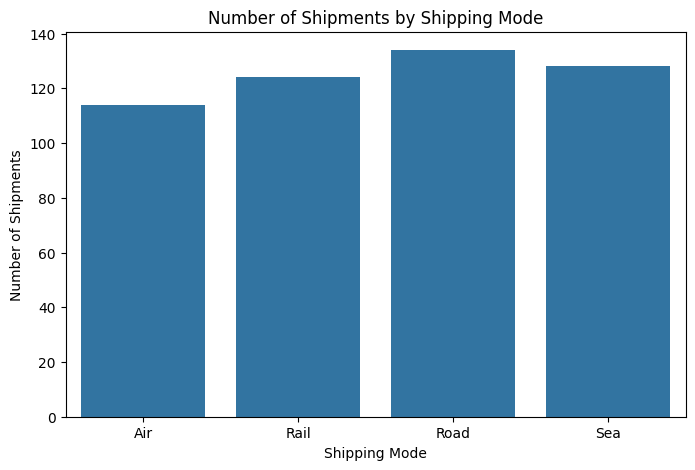

Shipping_Mode
Road    134
Sea     128
Rail    124
Air     114
Name: count, dtype: int64


In [7]:
# STEP 7: SHIPPING MODE ANALYSIS

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Shipping_Mode")
plt.title("Number of Shipments by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Number of Shipments")
plt.show()

print(df["Shipping_Mode"].value_counts())

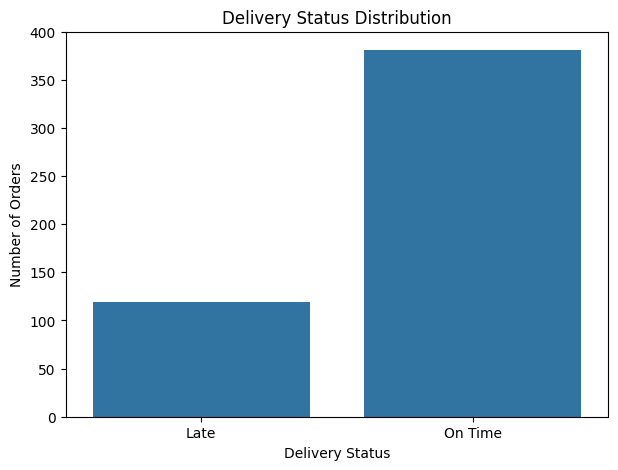

Delivery_Status
On Time    381
Late       119
Name: count, dtype: int64


In [8]:
# STEP 8: DELIVERY STATUS ANALYSIS

plt.figure(figsize=(7,5))
sns.countplot(data=df, x="Delivery_Status")
plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")
plt.show()

print(df["Delivery_Status"].value_counts())

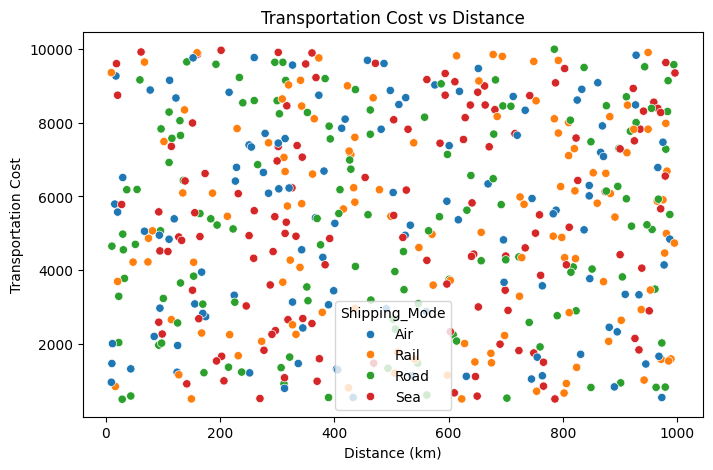

In [9]:
# STEP 9: COST VS DISTANCE

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="Distance_km",
    y="Transportation_Cost",
    hue="Shipping_Mode"
)
plt.title("Transportation Cost vs Distance")
plt.xlabel("Distance (km)")
plt.ylabel("Transportation Cost")
plt.show()

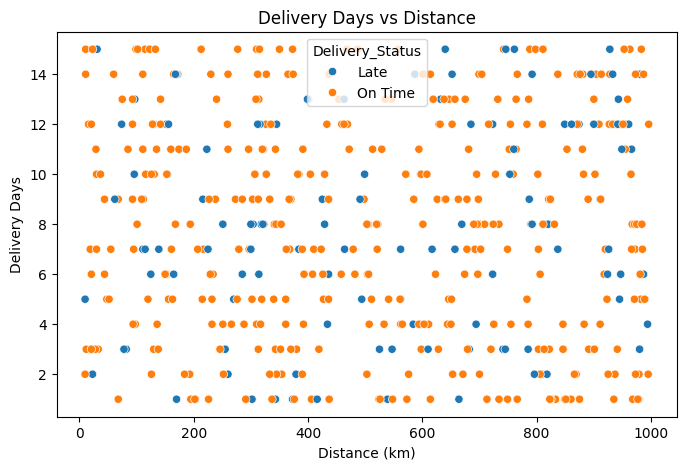

In [10]:
# STEP 10: DELIVERY DAYS VS DISTANCE

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="Distance_km",
    y="Delivery_Days",
    hue="Delivery_Status"
)
plt.title("Delivery Days vs Distance")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Days")
plt.show()

Shipping_Mode
Rail    5246.941694
Air     5302.798772
Road    5360.070672
Sea     5470.603828
Name: Transportation_Cost, dtype: float64


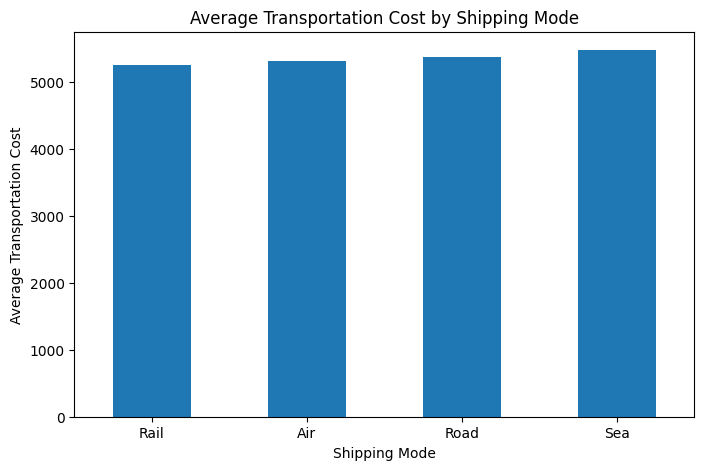

In [11]:
# STEP 11: AVERAGE COST BY SHIPPING MODE

mode_cost = df.groupby("Shipping_Mode")["Transportation_Cost"].mean().sort_values()

print(mode_cost)

plt.figure(figsize=(8,5))
mode_cost.plot(kind="bar")
plt.title("Average Transportation Cost by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Average Transportation Cost")
plt.xticks(rotation=0)
plt.show()

Shipping_Mode
Air     7.754386
Rail    7.758065
Sea     7.820312
Road    8.029851
Name: Delivery_Days, dtype: float64


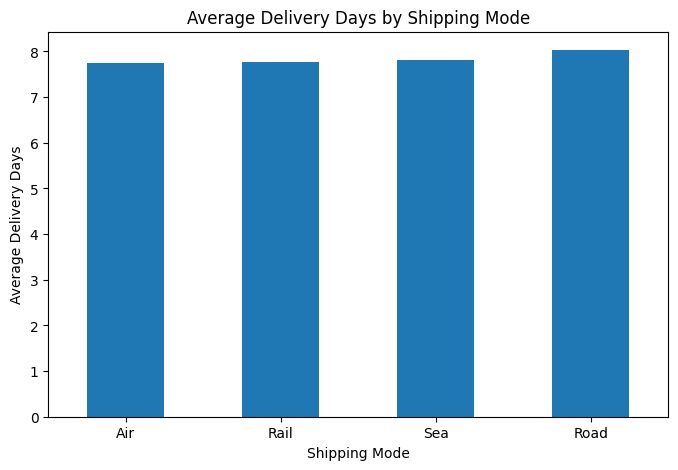

In [12]:
# STEP 12: AVERAGE DELIVERY DAYS BY SHIPPING MODE

mode_delivery = df.groupby("Shipping_Mode")["Delivery_Days"].mean().sort_values()

print(mode_delivery)

plt.figure(figsize=(8,5))
mode_delivery.plot(kind="bar")
plt.title("Average Delivery Days by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Average Delivery Days")
plt.xticks(rotation=0)
plt.show()

                     Delivery_Days  Shipment_Volume  Transportation_Cost  \
Delivery_Days             1.000000        -0.041756            -0.007650   
Shipment_Volume          -0.041756         1.000000            -0.035552   
Transportation_Cost      -0.007650        -0.035552             1.000000   
Distance_km              -0.012606         0.006554             0.046548   
Shipment_Weight_kg        0.016450         0.019338            -0.065443   
Customer_Rating           0.002224        -0.110723            -0.024297   

                     Distance_km  Shipment_Weight_kg  Customer_Rating  
Delivery_Days          -0.012606            0.016450         0.002224  
Shipment_Volume         0.006554            0.019338        -0.110723  
Transportation_Cost     0.046548           -0.065443        -0.024297  
Distance_km             1.000000            0.010856         0.007671  
Shipment_Weight_kg      0.010856            1.000000        -0.003544  
Customer_Rating         0.007671   

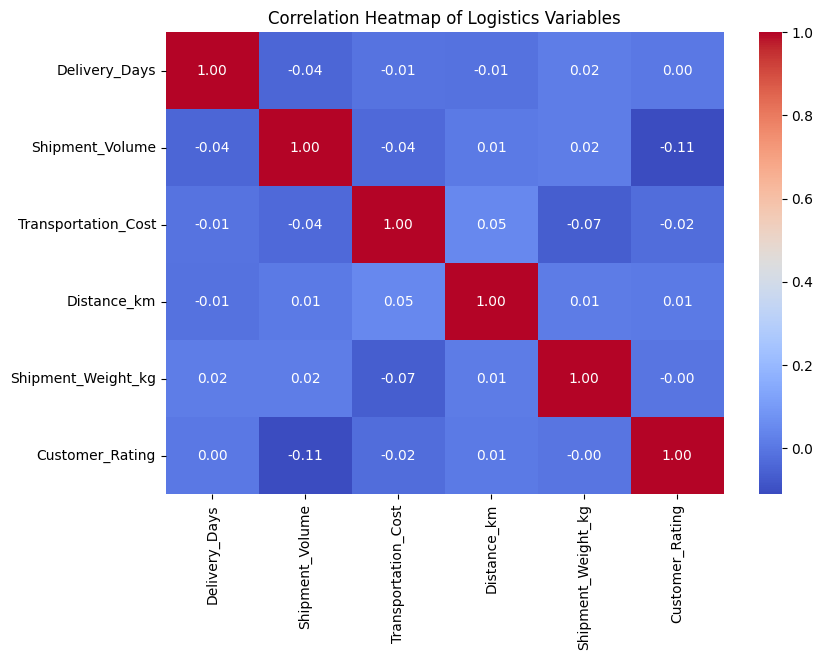

In [13]:
# STEP 13: CORRELATION ANALYSIS

correlation = df[numeric_cols].corr()

print(correlation)

plt.figure(figsize=(9,6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Logistics Variables")
plt.show()

In [14]:
# STEP 14: KEY LOGISTICS KPIs

total_orders = len(df)
average_delivery = df["Delivery_Days"].mean()
average_cost = df["Transportation_Cost"].mean()
average_distance = df["Distance_km"].mean()
late_orders = (df["Delivery_Status"] == "Late").sum()
late_rate = (late_orders / total_orders) * 100

print("===== LOGISTICS KPI SUMMARY =====")
print("Total Orders:", total_orders)
print("Average Delivery Days:", round(average_delivery, 2))
print("Average Transportation Cost:", round(average_cost, 2))
print("Average Distance (km):", round(average_distance, 2))
print("Late Orders:", late_orders)
print("Late Delivery Rate:", round(late_rate, 2), "%")

===== LOGISTICS KPI SUMMARY =====
Total Orders: 500
Average Delivery Days: 7.85
Average Transportation Cost: 5347.25
Average Distance (km): 513.77
Late Orders: 119
Late Delivery Rate: 23.8 %


In [15]:
# STEP 15: INSIGHT TABLES

print("===== SHIPPING MODE PERFORMANCE =====")

mode_analysis = df.groupby("Shipping_Mode").agg(
    Average_Delivery_Days=("Delivery_Days", "mean"),
    Average_Cost=("Transportation_Cost", "mean"),
    Average_Distance=("Distance_km", "mean"),
    Total_Shipments=("Order_ID", "count")
).round(2)

print(mode_analysis)

print("\n===== DELIVERY STATUS PERFORMANCE =====")

status_analysis = df.groupby("Delivery_Status").agg(
    Average_Delivery_Days=("Delivery_Days", "mean"),
    Average_Cost=("Transportation_Cost", "mean"),
    Average_Distance=("Distance_km", "mean"),
    Orders=("Order_ID", "count")
).round(2)

print(status_analysis)

===== SHIPPING MODE PERFORMANCE =====
               Average_Delivery_Days  Average_Cost  Average_Distance  \
Shipping_Mode                                                          
Air                             7.75       5302.80            485.42   
Rail                            7.76       5246.94            568.02   
Road                            8.03       5360.07            494.48   
Sea                             7.82       5470.60            506.68   

               Total_Shipments  
Shipping_Mode                   
Air                        114  
Rail                       124  
Road                       134  
Sea                        128  

===== DELIVERY STATUS PERFORMANCE =====
                 Average_Delivery_Days  Average_Cost  Average_Distance  Orders
Delivery_Status                                                               
Late                              7.99       5599.42            529.73     119
On Time                           7.80       5268.49 

In [16]:
# STEP 16: SAVE ANALYZED DATASET

df.to_csv("week3_logistics_dataset.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!
